In [1]:
from matplotlib import pyplot as plt
from pathlib import Path


import sys
sys.path.append('/grid/kinney/data/desmara/pacbio_regex_parser/bin')

from cluster_on_alignment import build_alignment_df, make_alignment_matrix, plot_pca_hexbin, plot_clustermap

In [3]:
bam_path = Path("/grid/kinney/data/desmara/2025_12_03_pac_bio_library_mapping_risLlib_001_002_003_004/aligning/bc2015.lib001_rotated.subsampled_10000.minimap2_lowNscore_aligned.sorted.bam")
alignment_df = build_alignment_df(bam_path, seed=42, max_reads=1000, drop_supplementary=True, drop_secondary=True)
alignment_df

,alignment_id,read_name,ref_name,ref_pos,query_pos,op,query_base,ref_base,is_match,is_mismatch
0,1,m84223_251126_143521_s2/86901355/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,NaN,0.0,I,G,NaN,False,False
1,1,m84223_251126_143521_s2/86901355/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,NaN,1.0,I,A,NaN,False,False
2,1,m84223_251126_143521_s2/86901355/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,1.0,3.0,M,T,T,True,False
3,1,m84223_251126_143521_s2/86901355/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,2.0,4.0,M,C,C,True,False
4,1,m84223_251126_143521_s2/86901355/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,3.0,5.0,M,T,T,True,False
...,...,...,...,...,...,...,...,...,...,...
4334748,1000,m84223_251126_143521_s2/172165301/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,4383.0,3128.0,M,A,A,True,False
4334749,1000,m84223_251126_143521_s2/172165301/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,4384.0,3129.0,M,G,G,True,False
4334750,1000,m84223_251126_143521_s2/172165301/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,4385.0,3130.0,M,A,A,True,False
4334751,1000,m84223_251126_143521_s2/172165301/ccs,library001_ris_sensative_SMN2_2xInner_2xBC_rot...,NaN,3130.0,I,T,NaN,False,False


In [4]:
matrix = make_alignment_matrix(alignment_df)
matrix

,ref_pos,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,...,4376.0,4377.0,4378.0,4379.0,4380.0,4381.0,4382.0,4383.0,4384.0,4385.0
read_name,alignment_id,,,,,,,,,,,,,,,,,,,,,
m84223_251126_143521_s2/100008114/ccs,950,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
m84223_251126_143521_s2/100205291/ccs,766,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
m84223_251126_143521_s2/100270721/ccs,289,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
m84223_251126_143521_s2/100535480/ccs,815,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
m84223_251126_143521_s2/100733867/ccs,569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
m84223_251126_143521_s2/98831714/ccs,702,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
m84223_251126_143521_s2/9899721/ccs,160,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
m84223_251126_143521_s2/99292210/ccs,374,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True


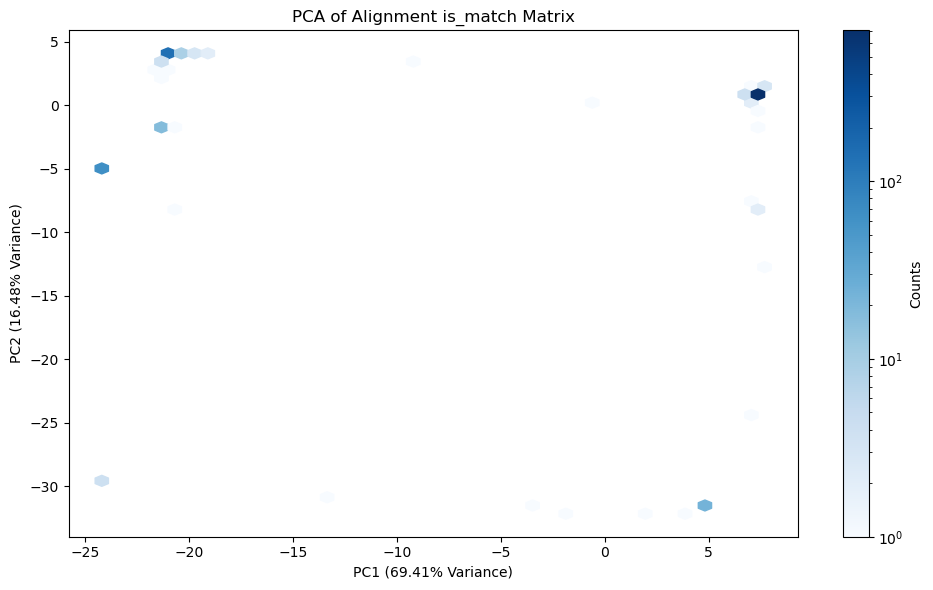

In [5]:
hexbin_fig = plot_pca_hexbin(matrix)
hexbin_fig.show()

/grid/kinney/home/desmara/.conda/envs/PacBio/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


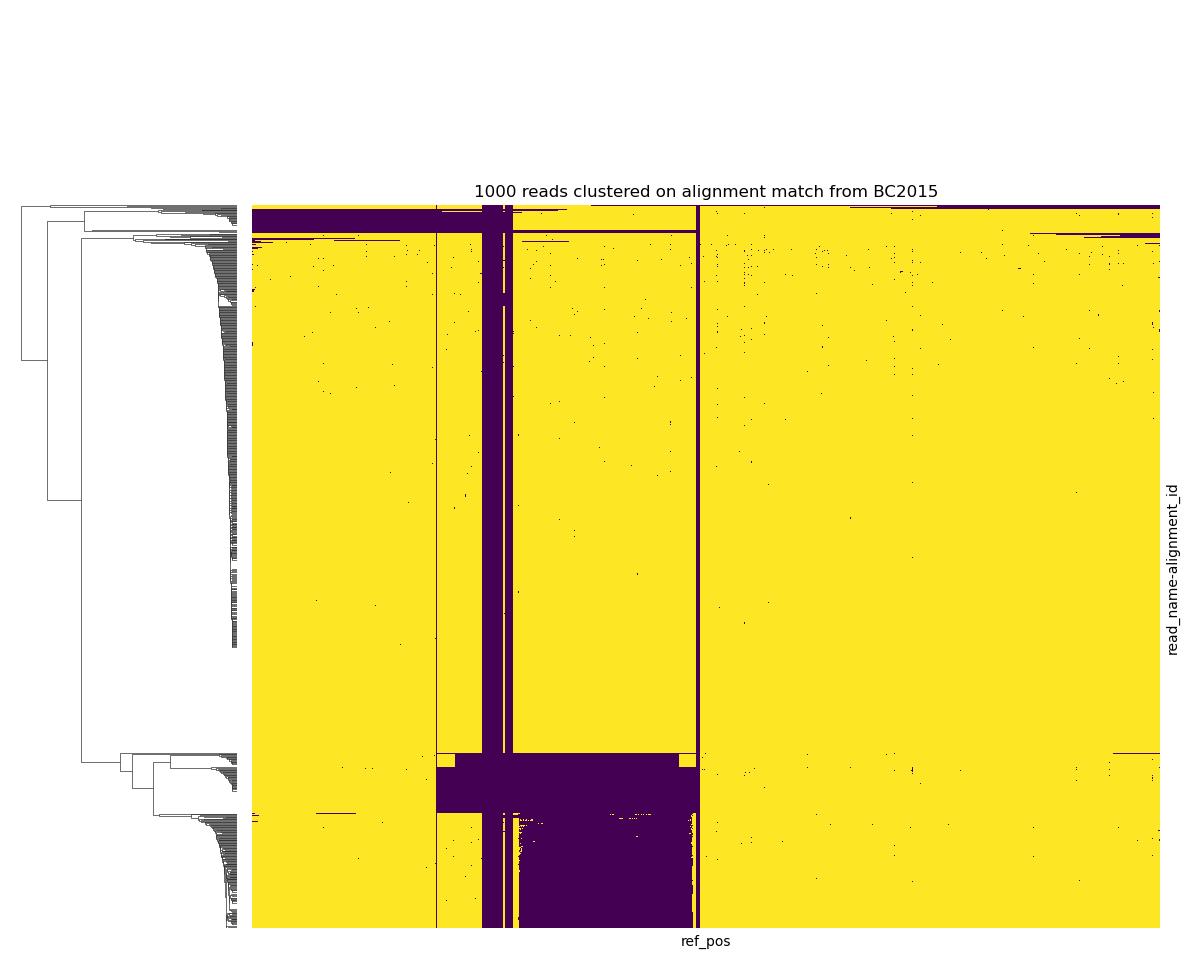

In [6]:
clustermap_grid = plot_clustermap(matrix.sample(1000))
plt.title("1000 reads clustered on alignment match from BC2015")
plt.suptitle("")
plt.show()